In [1]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn import ensemble, tree, linear_model

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
df = pd.read_csv('Maternal Health Risk Data Set.csv')

In [4]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [5]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [7]:
df.RiskLevel.value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [8]:
df['RiskLevel'] = df['RiskLevel'].replace({'low risk':1, 'mid risk': 2, 'high risk': 3})
df['RiskLevel']= df['RiskLevel'].astype('int')
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,3
1,35,140,90,13.0,98.0,70,3
2,29,90,70,8.0,100.0,80,3
3,30,140,85,7.0,98.0,70,3
4,35,120,60,6.1,98.0,76,1


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



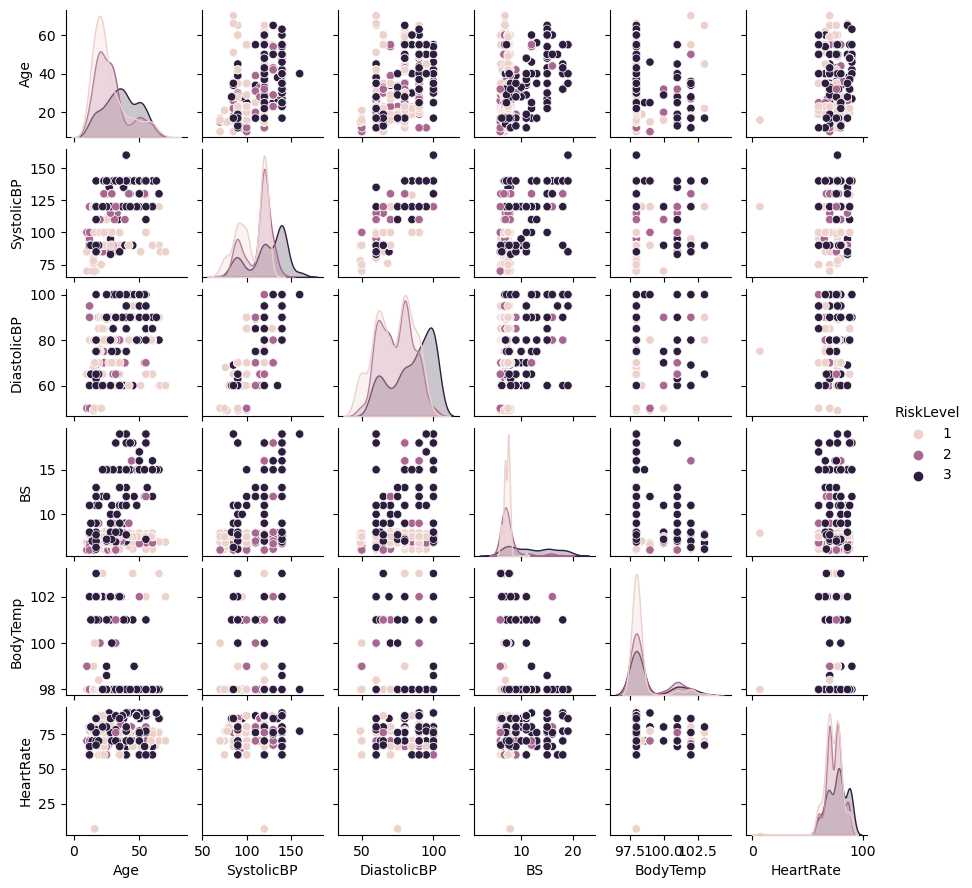

In [9]:
sns.pairplot(df,height=1.5,hue='RiskLevel')

<Axes: >

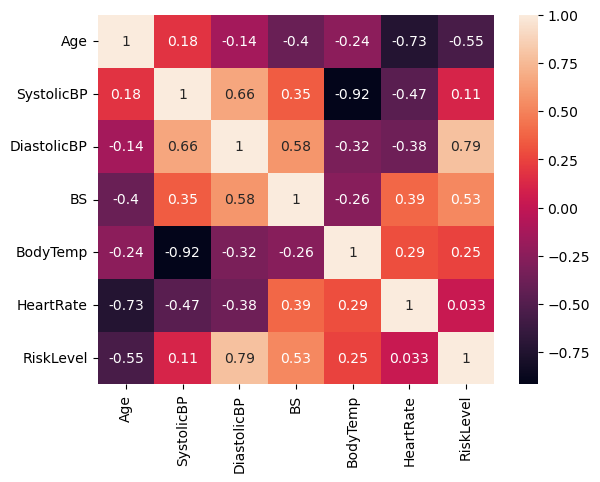

In [10]:
sns.heatmap(df[:5].corr(method ='pearson'), annot=True)

In [11]:
fig = px.box(df, x="Age", points='all',width=800, height=200)
fig.show()

In [12]:
print('Age min: {age}'.format(age = df['Age'].min()))
print('Age max: {age}'.format(age = df['Age'].max()))
print('Age avg: {age}'.format(age = df['Age'].mean()))
print('Age median: {age}'.format(age = df['Age'].median()))
print('Age std: {age}'.format(age = df['Age'].std()))

Age min: 10
Age max: 70
Age avg: 29.871794871794872
Age median: 26.0
Age std: 13.474385532634383


In [13]:
data = df[['Age']].value_counts().reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
fig = px.bar(data, x='Age', y='Count',width=800, height=400)
fig.update_layout(
    title='Number of people per Age',
    yaxis_title="Count")
fig.show()

In [14]:
data = df[['Age']].value_counts().reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
data = data.sort_values(by='Age')
fig = px.histogram(data, x="Age", y="Count",nbins=20,width=800, height=400)
fig.update_layout(
    title='Age histogram',
    yaxis_title="Sum of count")
fig.show()

In [15]:
sections = [(df['Age'] <= 14 ),\
           (df['Age'] >= 15) & (df['Age'] <=24),\
           (df['Age'] >= 25) & (df['Age'] <=64),\
           (df['Age'] > 64)]

choice =['children','youth','adult','senior']
df['Group'] = np.select(sections, choice)

#Visualization by Group
data = df[['Group']].value_counts(normalize=True).reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
fig = px.bar(data, x='Group', y='Count',width=800, height=400)
fig.update_layout(
    title='Percent per Group',
    yaxis_title="Count")
fig.show()

In [16]:
data = df[['SystolicBP','DiastolicBP']].value_counts().reset_index()
data.rename(columns={data.columns[2]:'count'}, inplace=True)
data.head()

,SystolicBP,DiastolicBP,count
0,120,80,204
1,120,90,112
2,90,60,67
3,140,100,63
4,90,65,53


In [17]:
fig = px.box(df, x="SystolicBP", points='all',width=800, height=200)
fig.show()
fig = px.box(df, x="DiastolicBP", points='all',width=800, height=200)
fig.show()

In [18]:
#Systolic BP values 
data = df[['SystolicBP']].value_counts(normalize =True).reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
fig = px.histogram(data, x='SystolicBP', y='Count',nbins=20,width=600, height=400)
fig.update_layout(
    title='Systolic BP count',
    yaxis_title="Count")
fig.show()

#Diastolic BP values
data = df[['DiastolicBP']].value_counts(normalize=True).reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
fig = px.histogram(data, x='DiastolicBP', y='Count',nbins=20,width=600, height=400)
fig.update_layout(
    title='Diastolic BPcount',
    yaxis_title="Count")
fig.show()

In [19]:
sections = [(df['SystolicBP'] < 120 ) & (df['DiastolicBP'] <80),\
           (df['SystolicBP'] >= 120) & (df['SystolicBP'] <=129) & (df['DiastolicBP'] < 80),\
           (df['SystolicBP'] >= 130) & (df['SystolicBP'] <=139) | (df['DiastolicBP'] >= 80) & (df['DiastolicBP'] <=89),\
           (df['SystolicBP'] >=140) | (df['DiastolicBP'] >= 90)]
choice =['normal','elevated','stage 1','stage 2']
df['Type'] = np.select(sections,choice)

In [20]:
data = df[['Type']].value_counts(normalize=True).reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
data = data.sort_values(by='Type')
fig = px.bar(data, x="Type", y="Count",width=800, height=400)
fig.update_layout(
    title='Type histogram',
    yaxis_title="Percent")
fig.show()

In [21]:
fig = px.box(df, x="BS", points='all',width=800, height=200)
fig.show()

In [22]:
data = df[['BS','Group']].value_counts().reset_index()
data.rename(columns={data.columns[2]:'Count'}, inplace=True)
fig = px.histogram(data, x='BS', y='Count',width=1000, height=400,nbins=40,facet_col='Group')
fig.update_layout(
    title='BS histogram',
    yaxis_title="Count")
fig.show()

In [23]:
sections = [(df['BS'] <= 8),\
           (df['BS'] > 8) & (df['BS'] <=11),\
           (df['BS'] > 11)
           ]
choice =['normal','prediabetes','diabetes']
df['BSlvl'] = np.select(sections,choice)

In [24]:
data = df[['BSlvl']].value_counts(normalize=True).reset_index()
data.rename(columns={data.columns[1]:'Count'}, inplace=True)
data = data.sort_values(by='BSlvl')
fig = px.bar(data, x="BSlvl", y="Count",width=800, height=400)
fig.update_layout(
    title='Blood Sugar level histogram',
    yaxis_title="Percent")
fig.show()

In [25]:
fig = px.scatter(df, x="Age", y="BS",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [26]:
#Systolic & Diastolic and BS relationship
fig = px.scatter(df, x="SystolicBP", y="BS",color="Group", trendline="ols",width=600, height=400)
fig.show()
fig = px.scatter(df, x="DiastolicBP", y="BS",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [27]:
data = df[['Group','BodyTemp']].value_counts().reset_index()
data.rename(columns={data.columns[2]:'Count'}, inplace=True)
fig = px.histogram(data, x='BodyTemp', y='Count',width=1000, height=400,nbins=40,facet_col='Group')
fig.update_layout(
    title='Body Temperature histogram',
    yaxis_title="Count")
fig.show()

In [28]:
#Systolic & Diastolic and Body Temperature relationship
fig = px.scatter(df, x="SystolicBP", y="BodyTemp",color="Group", trendline="ols",width=600, height=400)
fig.show()
fig = px.scatter(df, x="DiastolicBP", y="BodyTemp",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [29]:
#Boxplot distribution Heart Rate
fig = px.box(df, x="HeartRate", points='all',facet_row='Group')
fig.show()

In [30]:
#Histogram Heart Rate
data = df[['HeartRate','Group']].value_counts().reset_index()
data.rename(columns={data.columns[2]:'Count'}, inplace=True)
fig = px.histogram(data, x='HeartRate', y='Count',width=1000, height=400,nbins=40,facet_col='Group')
fig.update_layout(
    title='Heart Rate histogram',
    yaxis_title="Count")
fig.show()

In [31]:
#Heart Rate and Age relationship
fig = px.scatter(df, x="Age", y="HeartRate",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [32]:
#Heart Rate and Body Temperature relationship
fig = px.scatter(df, x="HeartRate", y="BodyTemp",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [33]:
#Histogram Heart Rate
data = df[['RiskLevel','Group']].value_counts().reset_index()
data.rename(columns={data.columns[2]:'Count'}, inplace=True)
fig = px.histogram(data, x='RiskLevel', y='Count',width=1000, height=400,nbins=40,facet_col='Group')
fig.update_layout(
    title='Risk Level histogram',
    yaxis_title="Count")
fig.show()

In [34]:
#Risk Level and Age relationship
fig = px.scatter(df, x="Age", y="RiskLevel",color="Group", trendline="ols",width=600, height=400)
fig.show()

In [35]:
#Histogram Heart Rate & Group & Age relationship
data = df[['RiskLevel','Group','Age']].value_counts().reset_index()
data.rename(columns={data.columns[3]:'Count'}, inplace=True)
fig = px.histogram(data, x='Age', y='Count',width=800, height=600,nbins=40,facet_col='Group',facet_row='RiskLevel')
fig.update_layout(
    title='Risk Level histogram')
fig.show()